# Image → SVG → syringe pipeline

This notebook runs entirely offline with the **synthetic simulation profile**. Run All creates a new audited run; it never contacts, homes or starts a printer. All implementation lives in `src/bioprinter`. The demo intentionally exposes uneven support, so preview success is not production approval.

Use the bioprinter `.venv` Python kernel. Install dependencies using `scripts/bootstrap.ps1` or `scripts/bootstrap.sh`.

In [1]:
from pathlib import Path
import os, json
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'pyproject.toml').exists(), 'Start Jupyter from the bioprinter folder'
if os.environ.get('BIOPRINTER_OFFLINE_TEST') == '1':
    import httpx
    def no_network(*args, **kwargs): raise AssertionError('Notebook must remain offline')
    httpx.Client.request = no_network
from IPython.display import display, Image, HTML
from bioprinter.config import load_profile
from bioprinter.external import doctor
PROFILE = load_profile(ROOT / 'profiles/synthetic.yaml')
capabilities = doctor(PROFILE)
display({'Python': capabilities['python'], 'profile': PROFILE.name,
         'external': {k: v.get('version', 'not found') for k,v in capabilities['external'].items()},
         'production_allowed': not PROFILE.missing(True)})

{'Python': '3.11.9',
 'profile': 'SYNTHETIC-only',
 'external': {'inkscape': 'not found',
  'prusa-slicer': 'not found',
  'ffmpeg': 'ffmpeg version 7.1-essentials_build-www.gyan.dev Copyright (c) 2000-2024 the FFmpeg developers',
  'ffprobe': 'ffprobe version 7.1-essentials_build-www.gyan.dev Copyright (c) 2007-2024 the FFmpeg developers'},
 'production_allowed': False}

## Folder, order and per-image settings

Natural filename order is deterministic. Set `ORDER` to a list of filenames to override it; repeated entries repeat designs. `SEQUENCES` can set different lists for Q1–Q4, including empty lists. All input originals are copied and hashed. Multi-page/animated inputs must be split first.

In [2]:
from bioprinter.ingestion import discover
INPUT_FOLDER = ROOT / 'examples/inputs'
ORDER = None
SEQUENCES = None  # e.g. {'Q1': ['image1_ring.png'], 'Q2': [], 'Q3': [], 'Q4': []}
PER_IMAGE = {'image1_ring.png': {'threshold': 128, 'simplify_mm': 0.05}}
assets = discover(INPUT_FOLDER, order=ORDER)
display([a.metadata() for a in assets])

[{'asset_id': '54d092eb1e2e-5e864e',
  'original_name': 'image1_ring.png',
  'source_path': 'C:\\Users\\Jeffr\\OneDrive\\Documents\\GitHub\\Mind_Progeny\\bioprinter\\examples\\inputs\\image1_ring.png',
  'sha256': '54d092eb1e2ef4252de19018f605a1a5fec8ecb37930f28c599752b27c0ec9f4'},
 {'asset_id': '88ebe4ba6c6d-e02a29',
  'original_name': 'image2_asymmetric_L.png',
  'source_path': 'C:\\Users\\Jeffr\\OneDrive\\Documents\\GitHub\\Mind_Progeny\\bioprinter\\examples\\inputs\\image2_asymmetric_L.png',
  'sha256': '88ebe4ba6c6d5dd2c9dc0269f76005d77c01726edc46f67f6442029f6ead1600'},
 {'asset_id': '332f97ca57d7-854703',
  'original_name': 'image10_bridge_island.png',
  'source_path': 'C:\\Users\\Jeffr\\OneDrive\\Documents\\GitHub\\Mind_Progeny\\bioprinter\\examples\\inputs\\image10_bridge_island.png',
  'sha256': '332f97ca57d7323b36a18c14c30bb3c2d3edfdc5d112f5f7ec40dc74b6a61d6f'}]

## Vectorization comparison

The custom backend extracts real filled polygons with holes. Inkscape is an explicit manual round-trip if no fixture-verified headless tracer is available: Path → Trace Bitmap, remove raster, save Plain SVG. Selecting `inkscape` never silently chooses Python. Existing SVG strokes become filled geometry; raster centerlines are unsupported.

[{'name': 'image1_ring.png',
  'backend': 'python-opencv-contour-hierarchy',
  'area_mm2': 226.82,
  'bounds_mm': (3.0, 3.8999999999999986, 20.1, 21.0)},
 {'name': 'image2_asymmetric_L.png',
  'backend': 'python-opencv-contour-hierarchy',
  'area_mm2': 122.055,
  'bounds_mm': (4.0, 3.5, 21.1, 19.0)},
 {'name': 'image10_bridge_island.png',
  'backend': 'python-opencv-contour-hierarchy',
  'area_mm2': 101.68,
  'bounds_mm': (2.0, 9.899999999999999, 22.1, 21.6)}]

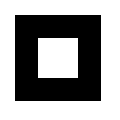

In [3]:
from bioprinter.vectorization import vectorize
from bioprinter.geometry import register, anchor_point
designs = [vectorize(a.path, width_mm=24) for a in assets]
display([{'name': a.path.name, 'backend': d.metadata['backend'], 'area_mm2': round(d.geometry.area, 3),
          'bounds_mm': d.geometry.bounds} for a,d in zip(assets,designs)])
display(Image(filename=str(assets[0].path)))

## Dimensions, anchors and registration

23 gauge and 12.7 mm needle length are the two individually confirmed specifications from the supplied brief. Bore, outer diameter, barrel and bead width are separate. Physical width is mandatory for raster input. Shared canvas is the default: preserve offsets and use a common scale across the stack. Bottom-left is design-local (0,0); the machine origin stays at plate center.

In [4]:
WIDTH_MM = 24.0
ANCHOR = 'bottom_left'
REGISTRATION = 'shared_canvas'
display({name: anchor_point(designs[0].geometry.bounds, name)
         for name in ['bottom_left','bottom_right','top_left','top_right','center']})
display(register(designs[0], ANCHOR, REGISTRATION).metadata)

{'bottom_left': (3.0, 3.8999999999999986),
 'bottom_right': (20.1, 3.8999999999999986),
 'top_left': (3.0, 21.0),
 'top_right': (20.1, 21.0),
 'center': (11.55, 12.45)}

{'backend': 'python-opencv-contour-hierarchy',
 'mode': 'filled',
 'width_mm': 24,
 'threshold': 128,
 'invert': False,
 'denoise': 0,
 'background': 'white',
 'min_area_mm2': 0,
 'simplify_mm': 0.05,
 'area_before_simplification_mm2': 226.82,
 'pixel_edge_uncertainty_mm': 0.2,
 'size_pixels': [120, 120],
 'anchor': 'bottom_left',
 'registration': 'shared_canvas',
 'source_to_local': [[0.2, 0.0, 0.0], [0.0, -0.2, 24.0], [0.0, 0.0, 1.0]],
 'local_to_source': [[5.0, 0.0, 0.0], [-0.0, -5.0, 120.0], [0.0, 0.0, 1.0]]}

## Slice and calibration settings

The demo explicitly selects direct polygon paths. PrusaSlicer uses a watertight mm-convention STL and records its probed CLI/config; it was not installed during development. Real 0.5 mm layers may be incompatible with the measured bore. Do not falsify a nozzle dimension to bypass that rejection. Top/bottom solid layers can override sparse infill.

Final E is calibrated relative syringe units. Filament E is converted to volume first, then divided by measured mm³/E; G92 does not refill capacity. No uncalibrated priming/retraction is reused.

In [5]:
BACKEND = 'direct'
PERIMETERS = 1
INFILL_DENSITY = 0.15
STACK_MODE = 'overlap_aware'
SCHEDULE = 'round_robin'
display({'layer_mm': PROFILE.deposition_height_mm, 'bead_width_mm': PROFILE.bead_width_mm,
         'mm3_per_E_unit': PROFILE.mm3_per_e_unit, 'capacity_mm3': PROFILE.capacity_mm3,
         'warning': 'These values are synthetic, not measurements'})

{'layer_mm': 0.5,
 'bead_width_mm': 1.0,
 'mm3_per_E_unit': 100.0,
 'capacity_mm3': 20000.0,
 'warning': 'These values are synthetic, not measurements'}

## Compose the stack and all four quadrants

Q1 top-right → Q2 bottom-right → Q3 bottom-left → Q4 top-left. Each design is applied to the height field in execution order. Sparse gaps and holes stay empty. At changes in support, lift/relocate instead of extruding through a vertical jump. Keyboard interrupt cancels between/within Python work; an incomplete run is never uploadable.

In [6]:
from bioprinter.pipeline import compose, preflight
RUN = compose(INPUT_FOLDER, PROFILE, output_root=ROOT/'runs', width_mm=WIDTH_MM,
              order=ORDER, sequences=SEQUENCES, per_image=PER_IMAGE,
              anchor=ANCHOR, registration=REGISTRATION, backend=BACKEND,
              perimeters=PERIMETERS, infill_density=INFILL_DENSITY,
              stack_mode=STACK_MODE, schedule_mode=SCHEDULE, progress=print)
print('Run:', RUN)
resolved, manifest = preflight(RUN, production=False)
display({'segments': len(manifest['events']), 'volume_mm3': manifest['used_mm3'],
         'production_blocking_diagnostics': manifest['diagnostics']})

Prepare 1/3: image1_ring.png
Prepare 2/3: image2_asymmetric_L.png
Prepare 3/3: image10_bridge_island.png
Compose 1/12: Q1 design 1
Compose 2/12: Q2 design 1
Compose 3/12: Q3 design 1


Compose 4/12: Q4 design 1
Compose 5/12: Q1 design 2
Compose 6/12: Q2 design 2
Compose 7/12: Q3 design 2
Compose 8/12: Q4 design 2


Compose 9/12: Q1 design 3
Compose 10/12: Q2 design 3
Compose 11/12: Q3 design 3
Compose 12/12: Q4 design 3


Run: C:\Users\Jeffr\OneDrive\Documents\GitHub\Mind_Progeny\bioprinter\runs\20260928T031628.215236Z_ce58a216


{'segments': 12,
 'volume_mm3': 481.3225107892893,
 'production_blocking_diagnostics': [{'event': 'event-0005',
   'severity': 'production-blocking',
   'issue': 'partially supported/variable-height footprint',
   'sample_count': 103,
   'reason': 'Model cannot establish continuous liquid support; change paths/order or validate a richer model'},
  {'event': 'event-0006',
   'severity': 'production-blocking',
   'issue': 'partially supported/variable-height footprint',
   'sample_count': 103,
   'reason': 'Model cannot establish continuous liquid support; change paths/order or validate a richer model'},
  {'event': 'event-0007',
   'severity': 'production-blocking',
   'issue': 'partially supported/variable-height footprint',
   'sample_count': 103,
   'reason': 'Model cannot establish continuous liquid support; change paths/order or validate a richer model'},
  {'event': 'event-0008',
   'severity': 'production-blocking',
   'issue': 'partially supported/variable-height footprint',
   

## G-code cleanup report

Modal parsing resolves XYZ/E modes, units and resets. Pure thermal/fan commands (including off commands) are removed. Unknown motions, arcs, macros, tool changes and mixed/nonthermal G10 forms reject. Every final file is serialized and reparsed against an allowlist. There is one coherent combined prologue and no homing at continuation boundaries.

In [7]:
cleanup = json.loads(next((RUN/'reports').glob('*.cleanup.json')).read_text())
display(cleanup)
print((RUN/'combined/combined.gcode').read_text()[:600])

{'actions': [{'line': 2, 'command': 'G21', 'action': 'normalized'},
  {'line': 3, 'command': 'G90', 'action': 'normalized'},
  {'line': 4, 'command': 'M82', 'action': 'normalized'}],
 'volume_mm3': 29.850000000018962}

; BIOPRINTER PREVIEW ONLY - SYNTHETIC/UNAPPROVED
; mm, absolute XYZ in centered machine frame; relative calibrated E
G21
G90
M83
G1 X0.000000 Y0.000000 Z2.600000 F480.000000
G1 X21.450000 Y70.450000 Z2.600000 F1800.000000
G1 X21.450000 Y70.450000 Z0.600000 F480.000000
G1 X21.937879 Y70.450000 Z0.600000 E0.002439394 F480.000000
G1 X22.425758 Y70.450000 Z0.600000 E0.002439394 F480.000000
G1 X22.913636 Y70.450000 Z0.600000 E0.002439394 F480.000000
G1 X23.401515 Y70.450000 Z0.600000 E0.002439394 F480.000000
G1 X23.889394 Y70.450000 Z0.600000 E0.002439394 F480.000000
G1 X24.377273 Y70.450000 Z0.600


## Quadrant and 3D motion preview

The image shows deposited paths and conservative surface heights. Open the self-contained Plotly HTML for rotation/zoom and travel visibility. These are geometric approximations; spreading, curing, pressure and liquid stability remain experimental.

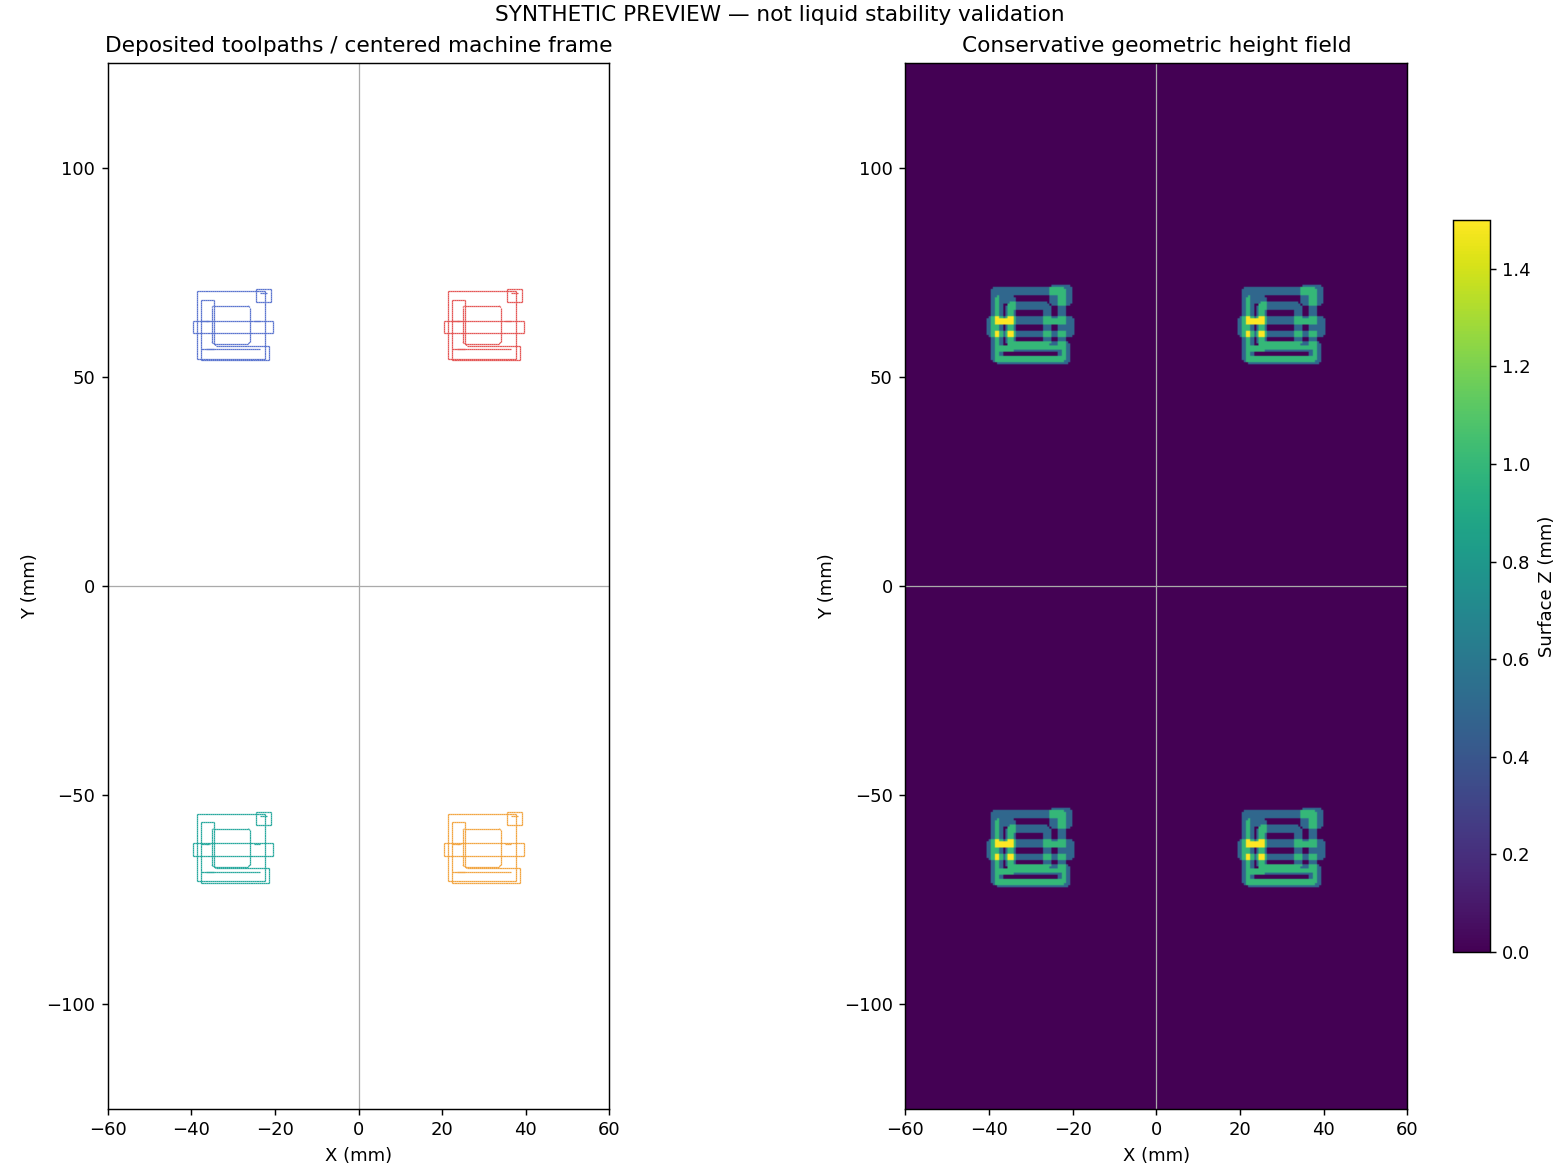

Interactive 3D: C:\Users\Jeffr\OneDrive\Documents\GitHub\Mind_Progeny\bioprinter\runs\20260928T031628.215236Z_ce58a216\previews\motion3d.html


In [8]:
display(Image(filename=str(RUN/'previews/plate.png')))
print('Interactive 3D:', RUN/'previews/motion3d.html')
display(HTML('<a href="../' + (RUN/'previews/motion3d.html').relative_to(ROOT).as_posix() + '" target="_blank">Open interactive 3D preview</a>'))

## Timeline, exact bytes and display player

Timing comes from final filtered G-code with axis and E limits, acceleration and zero junction speed. This is an estimate; transfer/firmware/pressure delays remain unknown. Display intervals cover the whole modeled motion schedule and hold the last image. Byte positions do not establish completed physical movement. Live observations are saved separately; pause holds the active image.

In [9]:
timeline = json.loads((RUN/'timing/display_timeline.json').read_text())
display(timeline['timing'])
display([{k: e[k] for k in ['event_id','quadrant','start_s','end_s','byte_start','byte_end']} for e in timeline['events']])
print('Offline display player:', RUN/'previews/display_player.html')

{'motion_s': 277.1885868096341,
 'dwell_s': 0.0,
 'transition_s': 172.2549272103957,
 'total_s': 449.44351402002593,
 'transfer_s': None,
 'status': 'estimated',
 'model': 'trapezoidal-full-stop-per-block-v1',
 'uncertainty': 'Uncalibrated; no numeric accuracy claim. Zero junction speed overestimates ideal lookahead; pressure and firmware overhead may add time.'}

[{'event_id': 'event-0001',
  'quadrant': 'Q1',
  'start_s': 0.0,
  'end_s': 43.51463469110705,
  'byte_start': 129,
  'byte_end': 15464},
 {'event_id': 'event-0002',
  'quadrant': 'Q2',
  'start_s': 43.51463469110705,
  'end_s': 88.40002185131017,
  'byte_start': 15464,
  'byte_end': 31059},
 {'event_id': 'event-0003',
  'quadrant': 'Q3',
  'start_s': 88.40002185131017,
  'end_s': 131.84129469833735,
  'byte_start': 31059,
  'byte_end': 46913},
 {'event_id': 'event-0004',
  'quadrant': 'Q4',
  'start_s': 131.84129469833735,
  'end_s': 177.2014945832975,
  'byte_start': 46913,
  'byte_end': 62510},
 {'event_id': 'event-0005',
  'quadrant': 'Q1',
  'start_s': 177.2014945832975,
  'end_s': 203.48560540959167,
  'byte_start': 62510,
  'byte_end': 71152},
 {'event_id': 'event-0006',
  'quadrant': 'Q2',
  'start_s': 203.48560540959167,
  'end_s': 232.08156057770765,
  'byte_start': 71152,
  'byte_end': 79939},
 {'event_id': 'event-0007',
  'quadrant': 'Q3',
  'start_s': 232.08156057770765,


Offline display player: C:\Users\Jeffr\OneDrive\Documents\GitHub\Mind_Progeny\bioprinter\runs\20260928T031628.215236Z_ce58a216\previews\display_player.html


## Optional MOV

Enable only if desired. FFmpeg is optional and has no effect on geometry/planning. Cumulative frame rounding avoids drift, the final frame receives its full interval, and ffprobe checks the output duration. A planned movie cannot follow arbitrary physical pauses.

In [10]:
MAKE_VIDEO = False
if MAKE_VIDEO:
    from bioprinter.video import create_video
    display(create_video(RUN, fps=2, size=(320,240)))
else:
    print('MOV skipped. Set MAKE_VIDEO=True to render this run.')

MOV skipped. Set MAKE_VIDEO=True to render this run.


## Optional explicit batch widgets

Reading this cell only creates controls. Click **Run offline batch** to create another timestamped run. Move up/down edits order, per-image JSON accepts threshold/size/registration settings, and **Cancel batch** requests cancellation at the next stage/segment boundary. Reruns preserve previous outputs.

In [11]:
from bioprinter.notebook_ui import batch_panel
batch_state = batch_panel(INPUT_FOLDER, PROFILE, ROOT/'runs')

## Printer controls — separate explicit invocation

Run All does not execute printer code. First fill `config.example.yaml`, mark measured fields, review the actual firmware/cold-extrusion/tool setup, and produce a clean `--production` run. Upload and start are separate. The synthetic run above is rejected by both.

From a terminal in this folder (these are documentation, not executable notebook cells):

```text
python -m bioprinter duet --url http://hans.local status
python -m bioprinter duet --url http://hans.local upload REAL_RUN --jobs
python -m bioprinter duet --url http://hans.local run-queue REAL_RUN --start --watch
python -m bioprinter duet --url http://hans.local run-queue REAL_RUN --confirm-completed job-0001
```

Standalone RRF cannot reliably prove cancellation vs successful completion from idle alone; the host queue waits for an operator to confirm physical completion before a successor can start. Confirm pose, deposited material and remaining syringe capacity. Never use a checkpoint as automatic physical resume. Pause/resume/cancel can invoke installed machine macros and require `--reviewed-macros`. Host control is not a physical emergency stop. See `docs/duet.md`.